# The run: actor-critic PPO on Qwen3-1.7B

[`01_actor_critic_and_gae.ipynb`](01_actor_critic_and_gae.ipynb) checked the mathematics
without a GPU. This one spends one. Same frozen data, same deterministic reward, same model
and the same clipped surrogate as
[`../../membrane_grpo/grpo_scratch.py`](../../membrane_grpo/grpo_scratch.py) — the baseline
is a learned $V_\phi(s_t)$ instead of a group mean, and the advantage is per token instead
of per sequence.

**Scale: this is a smoke test.** A short run on one card, not a converged training run.
Every claim below is scoped to that, exactly as `membrane_grpo`'s own README scopes its.

---

## Why this model, and why not the 0.5B any more

The model was chosen on the GRPO side by measurement rather than by argument
(`membrane_grpo/runs/sel-*`, three candidates on one ruler), and the two reasons that
decided it both apply here unchanged:

| frozen, dev, greedy | Qwen2.5-0.5B | **Qwen3-1.7B** |
| --- | --- | --- |
| schema valid | 0.005 | **0.970** |
| `cause_acc` | 0.145 | **0.255** |
| chance rate for `cause_acc` | 0.143 | 0.143 |
| `numeric_acc` | 0.000 | 0.038 |

The 0.5B's headline result was **confounded**: 52% of its reward gain was schema validity
going $0.005 \to 1.000$, which is formatting, not diagnosis. Here that headroom is worth at
most $0.003$, so a reward rise on this model cannot be explained away as format learning.
And its `cause_acc` sat *exactly* at the $1/7$ chance rate, leaving RL nothing partial to
sharpen; this one starts a real distance above it.

---

## Before running: the card has to be free

`anton` has a single RTX 5070 Ti, 16 GiB, and the vLLM 9B service normally holds ~14.6 GiB
of it. Nothing here will fit alongside it. Stopping the stack needs `sudo`, there is no
`NOPASSWD` rule on this machine, and `deploy/stack.sh` says so in its own header — so it is
**run by a person at a terminal, not by this notebook and not by an agent**:

```sh
deploy/stack.sh down                       # if you are on a branch that has it
sudo systemctl stop vllm-qwen membraneclaw-agent   # equivalent, any branch
```

and afterwards:

```sh
deploy/stack.sh up
```

The next cell refuses to continue rather than letting a run OOM twenty minutes in.

In [1]:
import sys, json, subprocess
from pathlib import Path

HERE = Path.cwd() if (Path.cwd() / "ppo_ac.py").exists() else Path("experiments/notebooks/smoke_test")
sys.path.insert(0, str(HERE.resolve()))

import torch
import ppo_ac
from ppo_ac import Config, train, resolve_device

# 11 GiB, not the 0.5B run's 8: Qwen3-1.7B is 3.4 GiB of bf16 weights before
# any activation, and the value head forces `output_hidden_states=True`, which
# keeps all 29 layers' hidden states alive through the backward pass.
MIN_FREE_MIB = 11000
BLOCKING_UNITS = ["vllm-qwen", "membraneclaw-agent"]

assert torch.cuda.is_available(), "no CUDA device; this notebook is the GPU half of the pair"
name = torch.cuda.get_device_name(0)

# Two sources, because on this machine they disagree and only one of them is right.
# `torch.cuda.mem_get_info` reported 13454 MiB free while nvidia-smi reported 544 --
# under WSL2 the CUDA driver counts memory it could page to host RAM as available to a
# new context. Trusting it starts a run that either crawls or dies twenty minutes in.
# nvidia-smi's number is the one that matches the card.
smi = subprocess.run(
    ["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,noheader,nounits"],
    capture_output=True, text=True,
)
used, total = (int(x) for x in smi.stdout.strip().split(", "))
torch_free = torch.cuda.mem_get_info()[0] // 2**20
free = total - used

print(f"{name}: {free} / {total} MiB free per nvidia-smi   (torch claims {torch_free}; "
      f"see the comment above for why they differ)")

busy = {u: subprocess.run(["systemctl", "is-active", u], capture_output=True, text=True).stdout.strip()
        for u in BLOCKING_UNITS}
running = [u for u, s in busy.items() if s == "active"]

if free < MIN_FREE_MIB or running:
    raise RuntimeError(
        f"the card is not free: {free} MiB available (need ~{MIN_FREE_MIB}), "
        f"still running {running or 'nothing'}.\n"
        f"From a terminal (needs sudo, no NOPASSWD rule here -- not from this notebook):\n"
        f"    sudo systemctl stop {' '.join(BLOCKING_UNITS)}\n"
        f"and afterwards:  sudo systemctl start {' '.join(BLOCKING_UNITS)}"
    )
print("card is free; the run may proceed")

NVIDIA GeForce RTX 5070 Ti: 15462 / 16303 MiB free per nvidia-smi   (torch claims 15009; see the comment above for why they differ)
card is free; the run may proceed


## The configuration, and why it is what it is

A step is 8 prompts × 1 sample = **8 sequences**. One sample per prompt is the point: the
algorithm does not need a second sample of the same prompt to form a baseline, because the
baseline is a learned function rather than a group mean.

Three settings changed with the model, and none of them by taste:

* **`value_lr` 5e-6 → 8.5e-6.** $|\Delta V| \approx \text{lr}\cdot\lVert h\rVert_1$, and
  `01` measures $\lVert h \rVert_1$ at **4323** on the 0.5B and **2308** here. More
  dimensions, far smaller activations. Porting the old value unchanged would have cut the
  critic's step in half on the model where the critic was already the slowest thing in the
  loop.
* **`value_init_bias` is looked up, not typed.** `ppo_ac.FROZEN_BASELINE` holds one number
  per `(model, weight set)` pair, because the reward is a weighted sum: this same frozen
  policy scores $0.3015$ under `MAIN`, $0.4500$ under `PROBE`, $0.2615$ under `ABLATE`.
* **`micro_batch` 2 → 1.** Qwen3-1.7B is 3.4 GiB of bf16 weights before any activation, and
  the value head forces `output_hidden_states=True`, which keeps all 29 layers' hidden
  states alive through the backward pass.

`eval_every=25` is new. It is not decoration: this method has already produced a run
(`runs/gonogo-stage-s0`) whose *training* reward sat at $1.0000$ for thirty steps while the
policy it was checkpointing was worth $0.000$ on dev. A reward curve alone cannot tell
learning from collapse.

In [2]:
cfg = Config(
    # model, steps, value_lr, micro_batch and value_init_bias all come from the
    # dataclass defaults now -- see ppo_ac.Config, where each is argued for.
    prompts_per_step=8,
    samples_per_prompt=1,     # the point: no group needed
    max_new_tokens=640,
    temperature=1.0,
    lr=1e-5,
    lam=1.0,                  # A_t = R - V(s_t); the honest default
    gamma=1.0,
    clip_eps=0.2,
    value_clip_eps=0.2,
    value_coef=0.5,
    value_detach=True,        # the critic is a probe, not a co-author of the trunk
    whiten_advantages=False,  # see 01: whitening would hide whether the critic works
    inner_epochs=1,           # at rho=1 the clip is inert by construction
    lora_r=16,
    weights="MAIN",
    seed=0,
    dtype="bfloat16",
    split="train",
)
tag = cfg.model.rsplit("/", 1)[-1].replace(".", "").lower()
OUT = HERE / "runs" / f"ppo-{tag}-{cfg.weights.lower()}-s{cfg.seed}"
print(json.dumps({k: v for k, v in cfg.__dict__.items() if k != "metrics"}, indent=2))
print(f"\nvalue head starts at {cfg.value_init_bias} "
      f"= frozen {cfg.model} on dev under {cfg.weights}")

{
  "model": "Qwen/Qwen3-1.7B",
  "steps": 200,
  "prompts_per_step": 8,
  "samples_per_prompt": 1,
  "max_new_tokens": 640,
  "temperature": 1.0,
  "lr": 1e-05,
  "value_lr": 8.5e-06,
  "weight_decay": 0.0,
  "gamma": 1.0,
  "lam": 1.0,
  "clip_eps": 0.2,
  "value_clip_eps": 0.2,
  "value_coef": 0.5,
  "value_detach": true,
  "whiten_advantages": false,
  "value_init_bias": 0.3015,
  "inner_epochs": 1,
  "micro_batch": 1,
  "normalize": "token",
  "lora_r": 16,
  "weights": "MAIN",
  "seed": 0,
  "dtype": "bfloat16",
  "split": "train",
  "prompt_version": "v2",
  "eval_every": 25,
  "eval_cases": 200,
  "eval_batch": 32,
  "eval_split": "dev",
  "eval_max_tokens": 640
}

value head starts at 0.3015 = frozen Qwen/Qwen3-1.7B on dev under MAIN


In [3]:
# Guarded so re-executing this notebook against a finished run plots it rather than
# spending another 35 minutes reproducing it. Delete the directory to force a rerun.
if (OUT / "metrics.jsonl").exists():
    history = None
    print(f"{OUT} already exists -- skipping training, plotting the stored run.")
    print("   delete the directory to train again.")
else:
    history = train(cfg, OUT, resolve_device("auto"))
    print(f"\n{len(history)} steps -> {OUT}")

/home/bayan/MembraneClaw/experiments/notebooks/smoke_test/runs/ppo-qwen3-17b-main-s0 already exists -- skipping training, plotting the stored run.
   delete the directory to train again.


## Curves

Six panels. The reward panel carries three reference lines, because a rising number means
nothing on its own: `membrane_grpo/baselines.py` priced two strategies that do not solve the
task — `constant` (valid JSON, the same guess every time) at **0.245** and `skip_correction`
(every field right except the temperature correction) at **0.890** — and the frozen policy's
own held-out reward under these exact weights is the third. Qwen3-1.7B starts *above* the
constant guesser at 0.3015; the 0.5B started below it, which is a different situation.

The bottom-left panel is the one to read. `cause_acc` at 1/7 = 0.143 is chance, and a run
whose reward climbs while that line stays flat has improved something other than the
diagnosis.

ppo-qwen3-17b-main-s0: 200 steps, 9 evaluations
  frozen policy under MAIN: 0.3015

  held out          step 0  step 200     delta
  reward            0.3015    0.3273   +0.0258
  cause_acc         0.2350    0.2900   +0.0550
  flags_acc         0.3233    0.2700   -0.0533
  numeric_acc       0.0350    0.0283   -0.0067
  action_acc        0.1750    0.2050   +0.0300
  schema_ok         0.9650    0.9950   +0.0300
  exact_match       0.0000    0.0000   +0.0000


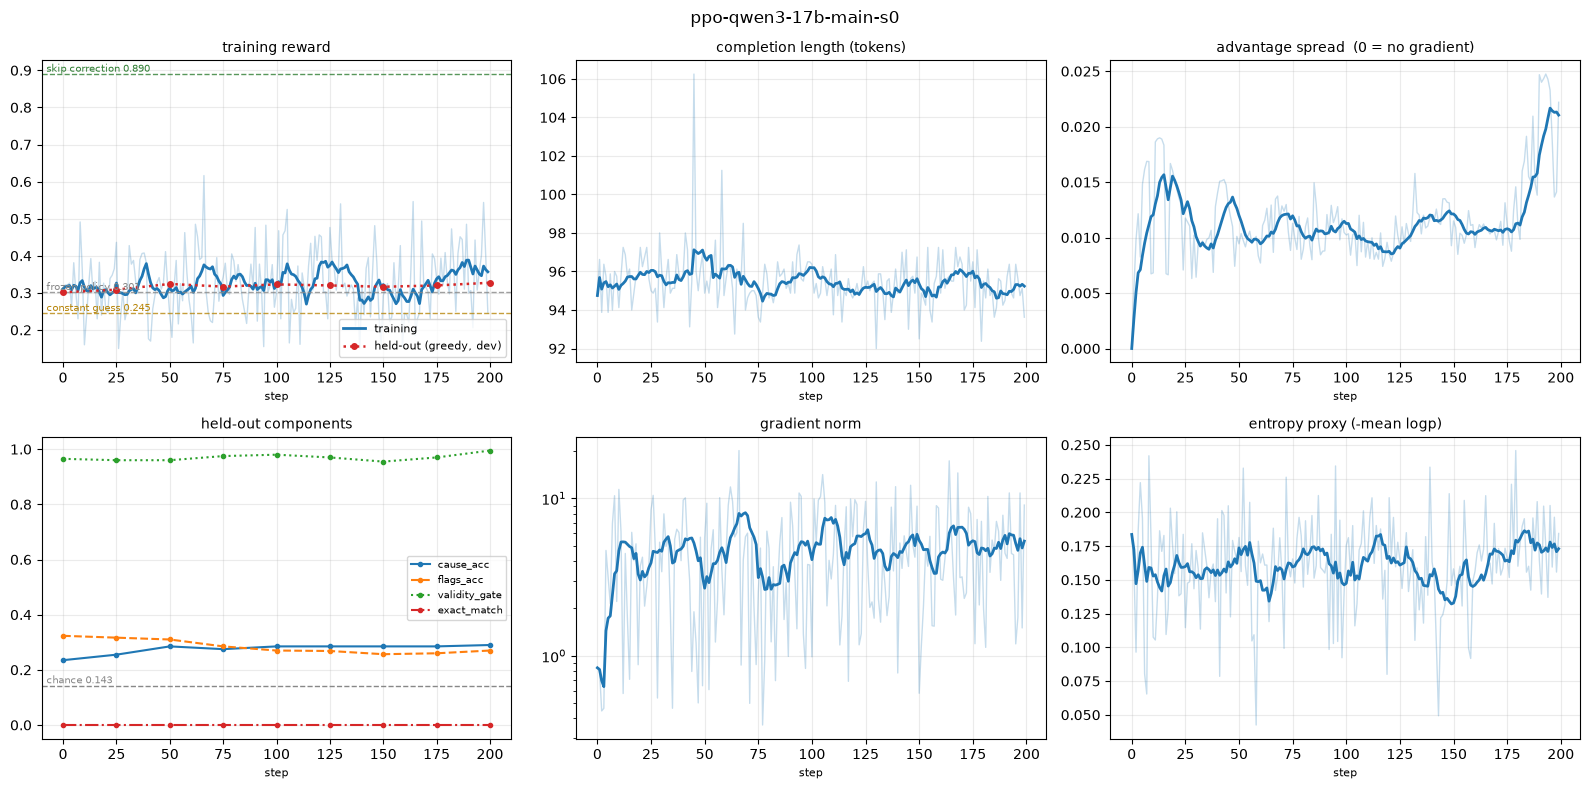

In [4]:
import matplotlib.pyplot as plt


def load_jsonl(path):
    path = Path(path)
    if not path.exists():
        return []
    return [json.loads(l) for l in path.read_text().splitlines() if l.strip()]


def smooth(values, window=9):
    return [
        sum(values[max(0, i - window + 1) : i + 1]) / len(values[max(0, i - window + 1) : i + 1])
        for i in range(len(values))
    ]


rows = load_jsonl(OUT / "metrics.jsonl")
evals = load_jsonl(OUT / "eval.jsonl")

# Priced in membrane_grpo/baselines.py; both are properties of the task, not of any
# model, so they carry across the model change unchanged. The frozen line does not --
# it is looked up per (model, weight set), because the reward is a weighted sum.
CONSTANT_GUESS, SKIP_CORRECTION = 0.245, 0.890
FROZEN = ppo_ac.value_init_bias_for(cfg.model, cfg.weights)
CHANCE_CAUSE = 1 / 7

PANELS = (
    ("reward_mean", "training reward", False),
    ("completion_tokens", "completion length (tokens)", False),
    # Not `unique_completions`: with samples_per_prompt=1 that is the batch size on
    # every step and says nothing. `adv_std` is the analogous health check -- it is
    # what goes to zero when there is no gradient left.
    ("adv_std", "advantage spread  (0 = no gradient)", False),
    ("__held_out__", "held-out components", False),
    ("grad_norm", "gradient norm", True),
    ("entropy_proxy", "entropy proxy (-mean logp)", False),
)
EVAL_PANEL = ("cause_acc", "flags_acc", "validity_gate", "exact_match")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (key, title, log) in zip(axes.flat, PANELS):
    if key == "__held_out__":
        for j, metric in enumerate(EVAL_PANEL):
            ax.plot([e["step"] for e in evals], [e.get(metric, 0.0) for e in evals],
                    linestyle=["-", "--", ":", "-."][j % 4], marker="o", markersize=3,
                    linewidth=1.5, label=metric)
        ax.axhline(CHANCE_CAUSE, linestyle="--", linewidth=1, color="#888888")
        ax.annotate(f"chance {CHANCE_CAUSE:.3f}", xy=(0.01, CHANCE_CAUSE),
                    xycoords=("axes fraction", "data"), fontsize=7, color="#888888", va="bottom")
        ax.legend(fontsize=7)
    else:
        values = [float(r[key]) for r in rows if r.get(key) is not None]
        steps = [r["step"] for r in rows if r.get(key) is not None]
        ax.plot(steps, values, alpha=0.25, linewidth=1, color="C0")
        ax.plot(steps, smooth(values), linewidth=2, color="C0",
                label="training" if key == "reward_mean" else None)
        if log and any(v > 0 for v in values):
            ax.set_yscale("log")

    if key == "reward_mean":
        for value, name, colour in ((FROZEN, "frozen policy", "#888888"),
                                    (CONSTANT_GUESS, "constant guess", "#b8860b"),
                                    (SKIP_CORRECTION, "skip correction", "#2e7d32")):
            ax.axhline(value, linestyle="--", linewidth=1, color=colour, alpha=0.8)
            ax.annotate(f"{name} {value:.3f}", xy=(0.01, value),
                        xycoords=("axes fraction", "data"), fontsize=7, color=colour, va="bottom")
        # Training reward and held-out reward on one axis is the whole picture;
        # the gap between them is what "reward rose" has to be read against.
        ax.plot([e["step"] for e in evals], [e["reward"] for e in evals], marker="o",
                markersize=4, linestyle=":", linewidth=1.8, color="C3",
                label="held-out (greedy, dev)")
        ax.legend(fontsize=8, loc="lower right")  # the annotations live at the left edge

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("step", fontsize=8)
    ax.grid(alpha=0.25)

fig.suptitle(OUT.name, fontsize=12)
fig.tight_layout()
fig.savefig(OUT / "curves.png", dpi=140)

# The numbers too, so they are quotable without opening the image.
first, last = evals[0], evals[-1]
print(f"{OUT.name}: {len(rows)} steps, {len(evals)} evaluations")
print(f"  frozen policy under {cfg.weights}: {FROZEN:.4f}\n")
print(f"  {'held out':<14}{'step 0':>10}{'step ' + str(last['step']):>10}{'delta':>10}")
for k in ("reward", "cause_acc", "flags_acc", "numeric_acc", "action_acc", "schema_ok",
          "exact_match"):
    a, b = first.get(k, 0.0), last.get(k, 0.0)
    print(f"  {k:<14}{a:>10.4f}{b:>10.4f}{b - a:>+10.4f}")

## Is the critic a critic?

The question this notebook exists to ask, and the one `value_mae` cannot answer: a value
head that has collapsed to a constant still posts a respectable mean absolute error.
Explained variance is what says whether $V(s)$ is a function of $s$ at all.

* **explained variance** — $1 - \mathrm{Var}(G_t - V_t)/\mathrm{Var}(G_t)$ over the active
  tokens of a batch. Zero means the critic is doing exactly as well as predicting the mean
  of the returns; below zero means worse.
* **within-batch spread of $V$** — near zero means every token of every completion in the
  batch gets the same baseline, so $A_t = R - \text{const}$ and this has degenerated into
  REINFORCE with a moving average.
* **$|\Delta V|$ per step** against the $\text{lr}\cdot\lVert h\rVert_1$ bound `value_lr`
  was derived from. That bound assumes all 2048 coordinates move coherently through the
  features; the gradient $2(V-G)\,h$ takes each coordinate's sign from $h$'s own signs, so
  Adam's $\pm\text{lr}$ steps partly cancel in the dot product. Expect the measured step to
  sit well **under** the line — it is an upper bound, not a prediction.

median value_ev +0.0052   mean value_std 0.0123


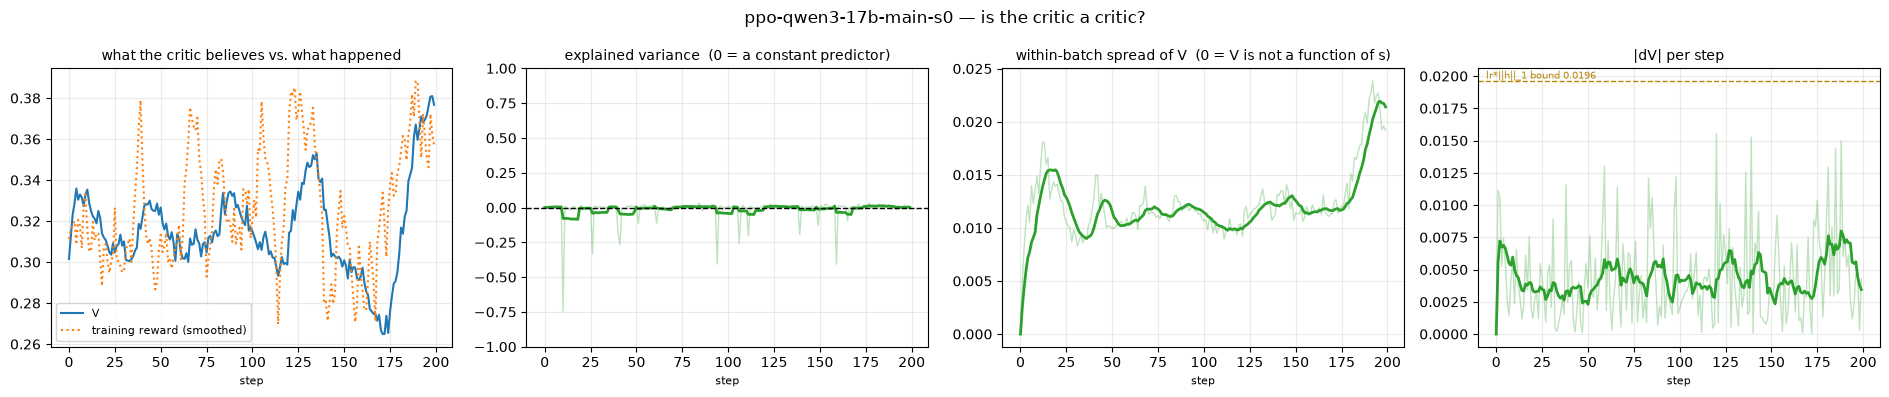

In [5]:
HIDDEN_L1 = 2308   # measured for this model in 01; the bound below is lr * ||h||_1

fig, axes = plt.subplots(1, 4, figsize=(19, 4))
steps = [r["step"] for r in rows]

axes[0].plot(steps, [r["value_mean"] for r in rows], color="C0", label="V")
axes[0].plot(steps, smooth([r["reward_mean"] for r in rows]), color="C1", linestyle=":",
             label="training reward (smoothed)")
axes[0].set_title("what the critic believes vs. what happened", fontsize=10)
axes[0].legend(fontsize=8)

for ax, (key, title) in zip(axes[1:], (
    ("value_ev", "explained variance  (0 = a constant predictor)"),
    ("value_std", "within-batch spread of V  (0 = V is not a function of s)"),
    ("value_step", "|dV| per step"),
)):
    values = [float(r.get(key, 0.0)) for r in rows]
    ax.plot(steps, values, alpha=0.3, linewidth=1, color="C2")
    ax.plot(steps, smooth(values), linewidth=2, color="C2")
    if key == "value_ev":
        ax.axhline(0.0, linestyle="--", linewidth=1, color="k")
        ax.set_ylim(-1.0, 1.0)
    if key == "value_step":
        bound = cfg.value_lr * HIDDEN_L1
        ax.axhline(bound, linestyle="--", linewidth=1, color="#b8860b")
        ax.annotate(f"lr*||h||_1 bound {bound:.4f}", xy=(0.02, bound),
                    xycoords=("axes fraction", "data"), fontsize=7, color="#b8860b", va="bottom")
    ax.set_title(title, fontsize=10)

for ax in axes:
    ax.set_xlabel("step", fontsize=8)
    ax.grid(alpha=0.25)
fig.suptitle(f"{OUT.name} — is the critic a critic?", fontsize=12)
fig.tight_layout()
fig.savefig(OUT / "critic.png", dpi=140)

ev = sorted(r.get("value_ev", 0.0) for r in rows)
print(f"median value_ev {ev[len(ev) // 2]:+.4f}"
      f"   mean value_std {sum(r.get('value_std', 0.0) for r in rows) / len(rows):.4f}")

## The ablation: does the weight on `numeric` matter here?

`MAIN` puts 0.45 on `root_cause` and 0.15 on `numeric`. `ABLATE` holds `numeric` at 0.35
while leaving `root_cause` substantial at 0.25. The hypothesis it tests is that the task is
a **chain** — `numeric → flags → cause` — so that weighting the head of the chain beats
weighting its tail, because the tail is only reachable through numbers the policy is
getting wrong.

```sh
../../membrane_grpo/.venv/bin/python ppo_ac.py --weights ABLATE
```

**Only the component accuracies are comparable between the two runs.** `reward` is a
weighted sum and the two runs use different weights, so their reward curves are denominated
in different units — the frozen policy scores 0.3015 under `MAIN` and 0.2615 under `ABLATE`
without changing at all. `cause_acc`, `numeric_acc`, `flags_acc` and `schema_ok` are plain
accuracies and carry across.

             cause_acc   numeric_acc     flags_acc     schema_ok
MAIN            0.2350        0.0350        0.3233        0.9650   <- step 0
                0.2900        0.0283        0.2700        0.9950   <- step 200
               +0.0550       -0.0067       -0.0533                 <- delta

ABLATE          0.2350        0.0350        0.3233        0.9650   <- step 0
                0.2850        0.0333        0.3183        0.9850   <- step 200
               +0.0500       -0.0017       -0.0050                 <- delta



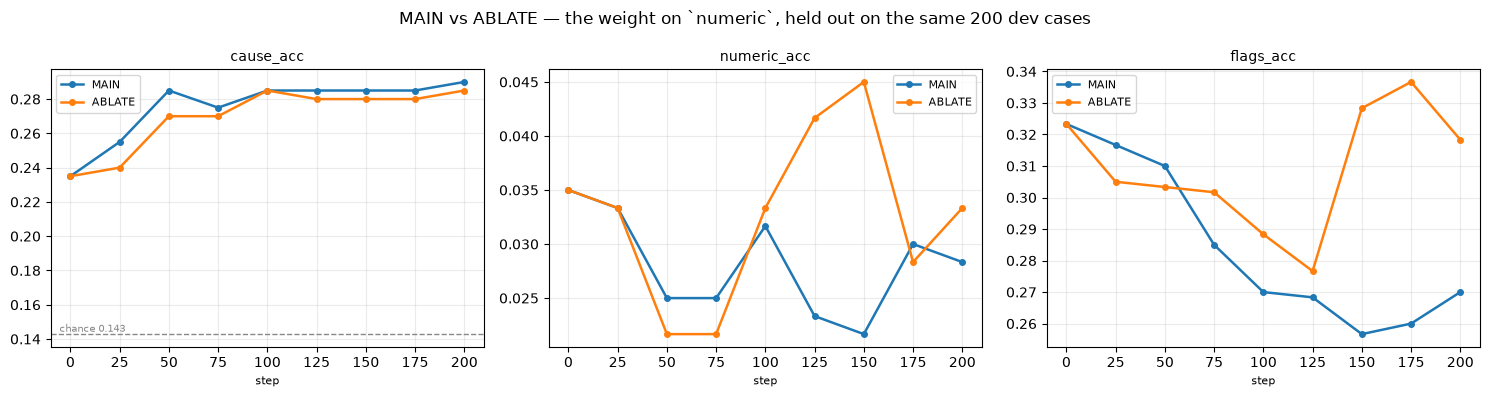

In [6]:
RUNS = {
    "MAIN":   HERE / "runs" / "ppo-qwen3-17b-main-s0",
    "ABLATE": HERE / "runs" / "ppo-qwen3-17b-ablate-s0",
}
curves = {name: load_jsonl(d / "eval.jsonl") for name, d in RUNS.items()}
curves = {k: v for k, v in curves.items() if v}

COMPARABLE = ("cause_acc", "numeric_acc", "flags_acc")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, COMPARABLE):
    for i, (name, ev) in enumerate(curves.items()):
        ax.plot([e["step"] for e in ev], [e[metric] for e in ev],
                marker="o", markersize=4, linewidth=1.8, color=f"C{i}", label=name)
    if metric == "cause_acc":
        ax.axhline(CHANCE_CAUSE, linestyle="--", linewidth=1, color="#888888")
        ax.annotate(f"chance {CHANCE_CAUSE:.3f}", xy=(0.02, CHANCE_CAUSE),
                    xycoords=("axes fraction", "data"), fontsize=7, color="#888888", va="bottom")
    ax.set_title(metric, fontsize=10)
    ax.set_xlabel("step", fontsize=8)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
fig.suptitle("MAIN vs ABLATE — the weight on `numeric`, held out on the same 200 dev cases",
             fontsize=12)
fig.tight_layout()
fig.savefig(HERE / "runs" / "main_vs_ablate.png", dpi=140)

width = max(len(n) for n in curves) + 2
print(f"{'':{width}}" + "".join(f"{m:>14}" for m in COMPARABLE + ("schema_ok",)))
for name, ev in curves.items():
    for label, e in (("step 0", ev[0]), (f"step {ev[-1]['step']}", ev[-1])):
        tag = name if label == "step 0" else ""
        print(f"{tag:{width}}" + "".join(f"{e[m]:>14.4f}" for m in COMPARABLE + ("schema_ok",))
              + f"   <- {label}")
    d = {m: ev[-1][m] - ev[0][m] for m in COMPARABLE}
    print(f"{'':{width}}" + "".join(f"{d[m]:>+14.4f}" for m in COMPARABLE) + f"{'':>14}   <- delta\n")

## The paired test

Every `cause_acc` number above is quoted from aggregates, and aggregates force the wrong
comparison. The independent-sample standard error on a proportion near $0.26$ over 200
cases is $0.031$, so $+0.055$ is about 1.8 SE and $+0.050$ is less — neither survives that
test, and the two are well inside noise of each other.

But these are not independent samples. They are the **same 200 cases, in the same order,
decoded greedily**. Almost every case is answered identically by both policies, and those
cases carry no information about the difference. Only the disagreements do, and McNemar's
exact test uses exactly them. It is the test the design called for all along.

Three greedy evaluations are needed — the frozen policy, the `MAIN` adapter, the `ABLATE`
adapter — each through `eval.generate_hf` so the per-case outcomes come from the same code
path that produced everything else here. `eval.summarise` writes the `per_case` block that
`paired_test` requires.

The reward weights are irrelevant to this test and `MAIN` is used for all three envelopes:
`cause`, `exact` and `schema` are per-case booleans, and no weight vector can change whether
a given completion named the right root cause.

In [7]:
import hashlib
import torch
from eval import generate_hf, summarise

PAIRED = HERE / "runs" / "paired"
PAIRED.mkdir(parents=True, exist_ok=True)

DEV = ppo_ac.DATA / "dev.jsonl"
SPLIT_SHA = hashlib.sha256(DEV.read_bytes()).hexdigest()
dev_cases = [json.loads(l) for l in DEV.read_text().splitlines()][: cfg.eval_cases]

POLICIES = {
    "base":   None,                          # the frozen policy, no adapter
    "main":   RUNS["MAIN"] / "adapter",
    "ablate": RUNS["ABLATE"] / "adapter",
}

for name, adapter in POLICIES.items():
    dest = PAIRED / f"{name}.json"
    if dest.exists():
        print(f"{dest.name} already written, skipping")
        continue
    results = generate_hf(
        dev_cases,
        model=cfg.model,
        device=resolve_device("auto"),
        dtype=cfg.dtype,
        n=1,
        temperature=0.0,                     # greedy: the policy is the only thing varying
        max_tokens=cfg.eval_max_tokens,
        seed=cfg.seed,
        batch_size=cfg.eval_batch,
        adapter=str(adapter) if adapter else None,
        prompt_version=cfg.prompt_version,
    )
    overall = summarise(results, ppo_ac.WEIGHT_SETS["MAIN"])
    # The same envelope eval.py writes, so paired_test.py reads these unmodified.
    dest.write_text(json.dumps({
        "model": cfg.model,
        "backend": "hf",
        "split": cfg.eval_split,
        "split_sha256": SPLIT_SHA,
        "prompt_version": cfg.prompt_version,
        "weights": "MAIN",
        "mode": "greedy",
        "k": 1,
        "temperature": 0.0,
        "max_tokens": cfg.eval_max_tokens,
        "seed": cfg.seed,
        "adapter": str(adapter) if adapter else None,
        "overall": overall,
    }, indent=2, default=str) + "\n")
    print(f"  {name:8s} reward {overall['reward']:.4f}  cause {overall['cause_acc']:.3f}"
          f"  -> {dest.name}")
    torch.cuda.empty_cache()

/home/bayan/MembraneClaw/experiments/membrane_grpo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:  61%|██████    | 190/311 [00:00<00:00, 1893.74it/s]

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 1983.98it/s]

  chat template honours enable_thinking; set to False


...

Loading weights:  60%|██████    | 187/311 [00:00<00:00, 1861.26it/s]

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 1915.02it/s]

  chat template honours enable_thinking; set to False


  ablate   reward 0.3302  cause 0.285  -> ablate.json


  200/200 cases


In [8]:
from paired_test import exact_binomial_two_sided


def per_case(name):
    payload = json.loads((PAIRED / f"{name}.json").read_text())
    if payload["split_sha256"] != SPLIT_SHA:
        raise SystemExit(f"{name} evaluated a different split; not comparable")
    return {r["id"]: r for r in payload["overall"]["per_case"]}


def mcnemar(before, after, metric="cause"):
    a, z = per_case(before), per_case(after)
    shared = sorted(set(a) & set(z))
    lost = [i for i in shared if a[i][metric] and not z[i][metric]]
    gained = [i for i in shared if not a[i][metric] and z[i][metric]]
    p = exact_binomial_two_sided(len(lost), len(gained))
    acc_a = sum(bool(a[i][metric]) for i in shared) / len(shared)
    acc_z = sum(bool(z[i][metric]) for i in shared) / len(shared)
    return {"n": len(shared), "before": acc_a, "after": acc_z,
            "lost": len(lost), "gained": len(gained),
            "discordant": len(lost) + len(gained), "p": p}


print("McNemar's exact test on `cause`, 200 paired dev cases, greedy\n")
head = f"  {'comparison':<22}{'before':>8}{'after':>8}{'gained':>8}{'lost':>7}{'discord':>9}{'p':>10}"
print(head)
print("  " + "-" * (len(head) - 2))
for before, after, label in (("base", "main", "base -> MAIN"),
                             ("base", "ablate", "base -> ABLATE"),
                             ("main", "ablate", "MAIN -> ABLATE")):
    r = mcnemar(before, after)
    print(f"  {label:<22}{r['before']:>8.3f}{r['after']:>8.3f}{r['gained']:>8d}"
          f"{r['lost']:>7d}{r['discordant']:>9d}{r['p']:>10.4f}")

print("\n  Only the discordant pairs carry information. A p above 0.05 means the split")
print("  between gained and lost is not distinguishable from a coin flip.")

McNemar's exact test on `cause`, 200 paired dev cases, greedy

  comparison              before   after  gained   lost  discord         p
  ------------------------------------------------------------------------
  base -> MAIN             0.235   0.290      13      2       15    0.0074
  base -> ABLATE           0.235   0.285      13      3       16    0.0213
  MAIN -> ABLATE           0.290   0.285       0      1        1    1.0000

  Only the discordant pairs carry information. A p above 0.05 means the split
  between gained and lost is not distinguishable from a coin flip.


## The ablations worth running next

$\lambda$ is the one dial that decides what per-token credit assignment *means*.
`--lam 1.0` is $A_t = R - V(s_t)$, unbiased and noisy; `--lam 0.0` is pure bootstrapping off
the critic — which, given the critic panels above, is expected to be much worse here rather
than merely lower-variance. Same seed, same data, one flag:

```sh
V=../../membrane_grpo/.venv/bin/python
$V ppo_ac.py --lam 0.0             --out runs/ppo-qwen3-17b-lam0-s0
$V ppo_ac.py --whiten-advantages 1 --out runs/ppo-qwen3-17b-whitened-s0
$V ppo_ac.py --value-init-bias 0   --out runs/ppo-qwen3-17b-cold-critic-s0
```

The third is expected to fail in the specific way `01` predicts: a critic starting at zero
cannot produce a negative advantage against a non-negative reward, so the first updates
reinforce every completion including the worthless ones. If it does not fail that way, the
argument in `01` is wrong and should be corrected here. The failure should be *larger* than
it was on the 0.5B — the gap between a cold head and a calibrated one is 0.30 here against
0.086 before.

The third is the one to run next. `--lam 0.0` bootstraps entirely off the critic, and given
the panels above — explained variance at zero, $V$ effectively constant — it should be
markedly *worse* than $\lambda = 1$ rather than merely lower-variance. That is a falsifiable
prediction about a critic this file has already measured, which makes it worth a run.

## What this run does and does not show

**Does**: that the loop is correct end to end on real hardware at this scale, that a
learned baseline produces a usable gradient on every step, and — via the critic panels —
that the baseline is *not* a function of the state on this model either. `value_ev` sits at
zero for all 200 steps and the within-batch spread of $V$ is about 0.012 against a mean of
0.32, so what actually trained the policy was $R$ minus a slowly drifting scalar.

**Does not**: settle anything about which method is better, or about $\lambda$, or about the
critic's ceiling once it is allowed to move faster. It is one seed, one weight set, 200
steps, and a critic that was deliberately left at its ported learning rate so the model
change was the only variable.

The frozen baseline is the reminder of how far there is to go: `cause_acc` 0.255 against a
$1/7 = 0.143$ chance rate, `numeric_acc` 0.038, and exact match of exactly 0.000 — three
percent changes all inside 0.5 pp remains out of reach at this scale.

For a claim about `cause_acc` moving, aggregates are the wrong test: the two evaluations are
the *same* 200 cases, so run `membrane_grpo/eval.py` against `adapter/` and
`membrane_grpo/paired_test.py` over the two `per_case` blocks.